In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 1: Data Pre-processing & Augmentation**                                    

We will use ImageDataGenerator to handle resizing, normalization, and data augmentation. This ensures the models are robust and don't overfit.

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import os

# 1. SETUP PATHS
path_disease = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path_growth = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

# 2. PRE-PROCESSING CONFIGURATION
# MobileNetV2 expects 224x224 images normalized to [0,1]
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% Train, 20% Validation
)

# 3. CREATE DATA LOADERS
def get_generators(path):
    train = datagen.flow_from_directory(path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training')
    val = datagen.flow_from_directory(path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation')
    return train, val

train_disease, val_disease = get_generators(path_disease)
train_growth, val_growth = get_generators(path_growth)

Found 1487 images belonging to 6 classes.
Found 369 images belonging to 6 classes.
Found 2745 images belonging to 6 classes.
Found 683 images belonging to 6 classes.


**Step 2: Build the MobileNetV2 Model Function**                                     
Instead of writing the model twice, we create a function. We use Transfer Learning by freezing the base layers of MobileNetV2 (trained on 1.4 million images).


In [7]:
def build_mobilenet(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze pre-trained weights

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize the two models
model_disease = build_mobilenet(train_disease.num_classes)
model_growth = build_mobilenet(train_growth.num_classes)

**Step 3: Training the Models**                            

We will train both. I've added EarlyStopping so the training stops once the model reaches its peak accuracy.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("--- Training Disease Model ---")
model_disease.fit(train_disease, validation_data=val_disease, epochs=10, callbacks=[early_stop])
model_disease.save('chili_disease_model.h5')

print("\n--- Training Growth Model ---")
model_growth.fit(train_growth, validation_data=val_growth, epochs=10, callbacks=[early_stop])
model_growth.save('chili_growth_model.h5')

--- Training Disease Model ---
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 222s 5s/step - accuracy: 0.7445 - loss: 0.7355 - val_accuracy: 0.8266 - val_loss: 0.4934
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9267 - loss: 0.2484 - val_accuracy: 0.8672 - val_loss: 0.3954
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9563 - loss: 0.1518 - val_accuracy: 0.8618 - val_loss: 0.3997
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9590 - loss: 0.1318 - val_accuracy: 0.8726 - val_loss: 0.3653
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.9677 - loss: 0.1058 - val_accuracy: 0.8753 - val_loss: 0.3637
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9724 - loss: 0.0889 - val_accuracy: 0.8808 - val_loss: 0.3477
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.9704 - loss: 0.0868 - val_accuracy: 0.8780 - val_loss: 0.4132
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9738 - loss: 0.


--- Training Growth Model ---
Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 901s 10s/step - accuracy: 0.5301 - loss: 0.9895 - val_accuracy: 0.2284 - val_loss: 1.4749
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.5607 - loss: 0.7973 - val_accuracy: 0.1493 - val_loss: 1.4916
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.5705 - loss: 0.7466 - val_accuracy: 0.1288 - val_loss: 1.5987


**Step 4: The Master Inference Script**                     

This is the "brain" of your project. It takes a single image and passes it through both models to give you a complete analysis.


In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image

def analyze_chili_leaf(img_path):
    # 1. Pre-process the single image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Get Predictions
    p_disease = model_disease.predict(img_array)
    p_growth = model_growth.predict(img_array)

    # 3. Map to Class Names
    # Note: dict.items() gives (folder_name, index)
    disease_labels = {v: k for k, v in train_disease.class_indices.items()}
    growth_labels = {v: k for k, v in train_growth.class_indices.items()}

    res_disease = disease_labels[np.argmax(p_disease)]
    res_growth = growth_labels[np.argmax(p_growth)]

    # 4. Final Output
    print("-" * 30)
    print(f"FILE: {os.path.basename(img_path)}")
    print(f"HEALTH STATUS: {res_disease} ({np.max(p_disease)*100:.2f}%)")
    print(f"GROWTH STAGE:  {res_growth} ({np.max(p_growth)*100:.2f}%)")
    print("-" * 30)

# TEST IT
# Replace with a path to a real image from your drive
test_img = "/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/test_sample.jpg"
if os.path.exists(test_img):
    analyze_chili_leaf(test_img)

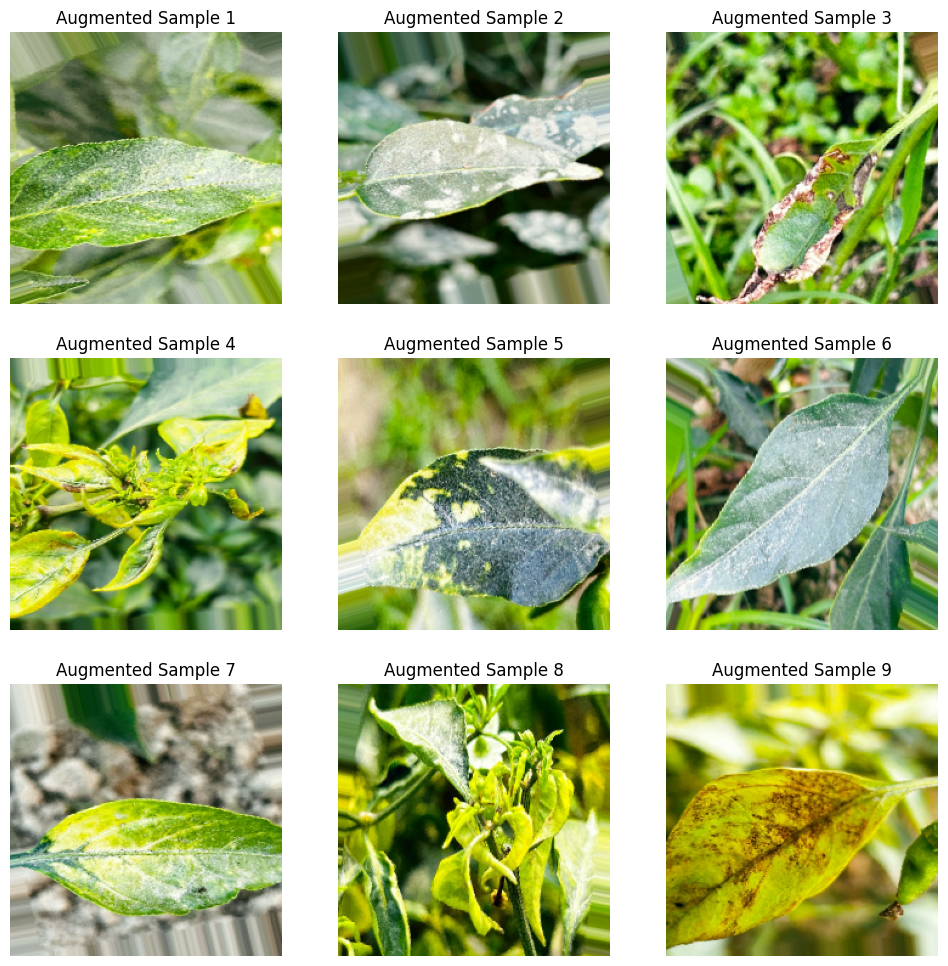

In [10]:
import matplotlib.pyplot as plt

# Grab one batch of 32 images from the Disease generator
x_batch, y_batch = next(train_disease)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    # This shows how the 'datagen' has slightly rotated or zoomed the original images
    plt.imshow(x_batch[i])
    plt.title(f"Augmented Sample {i+1}")
    plt.axis('off')
plt.show()

In [11]:
# Create a dedicated folder for your models in Drive
model_save_path = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models'
os.makedirs(model_save_path, exist_ok=True)

# Save the Disease Model
model_disease.save(f'{model_save_path}/chili_disease_mobilenet.h5')
print(f"✅ Disease Model saved to: {model_save_path}/chili_disease_mobilenet.h5")

# Save the Growth Stage Model
model_growth.save(f'{model_save_path}/chili_growth_mobilenet.h5')
print(f"✅ Growth Model saved to: {model_save_path}/chili_growth_mobilenet.h5")

✅ Disease Model saved to: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_disease_mobilenet.h5
✅ Growth Model saved to: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_growth_mobilenet.h5


In [12]:
from tensorflow.keras.models import load_model

# Load them back
model_disease = load_model('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_disease_mobilenet.h5')
model_growth = load_model('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_growth_mobilenet.h5')

print("🚀 Models loaded successfully! You can now use analyze_chili_leaf() immediately.")

🚀 Models loaded successfully! You can now use analyze_chili_leaf() immediately.


In [13]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Define the paths where you saved the models
model_path = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models'

# Load the models
model_disease = load_model(f'{model_path}/chili_disease_mobilenet.h5')
model_growth = load_model(f'{model_path}/chili_growth_mobilenet.h5')

print("✅ Models loaded and ready for testing!")

✅ Models loaded and ready for testing!


In [14]:
def predict_image(img_path):
    # Step A: Load and Resize image to 224x224
    img = image.load_img(img_path, target_size=(224, 224))

    # Step B: Convert to Numpy Array and Scale pixels (0 to 1)
    img_array = image.img_to_array(img) / 255.0

    # Step C: Add a 'Batch' dimension (MobileNet expects [1, 224, 224, 3])
    img_array = np.expand_dims(img_array, axis=0)

    # Step D: Run Inference
    disease_preds = model_disease.predict(img_array)
    growth_preds = model_growth.predict(img_array)

    # Step E: Get the index of the highest probability
    disease_idx = np.argmax(disease_preds)
    growth_idx = np.argmax(growth_preds)

    return disease_idx, growth_idx, np.max(disease_preds), np.max(growth_preds)

In [30]:
# 1. GET THE SOURCE OF TRUTH FROM YOUR GENERATORS
# These dictionaries map {'Class_Name': Index}
disease_map = train_disease.class_indices
growth_map = train_growth.class_indices

# 2. REVERSE THEM TO MAP {Index: 'Class_Name'}
# This ensures index 0 always points to the correct folder name
disease_labels = {v: k for k, v in disease_map.items()}
growth_labels = {v: k for k, v in growth_map.items()}

# 3. UPDATED PREDICTION FUNCTION
def final_predict(img_path):
    # Pre-processing
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Model Inference
    d_preds = model_disease.predict(img_array)
    g_preds = model_growth.predict(img_array)

    # Get Indices
    d_idx = np.argmax(d_preds)
    g_idx = np.argmax(g_preds)

    # OUTPUT USING THE NEW LABELS
    print("-" * 40)
    print(f"FILE: {os.path.basename(img_path)}")
    print(f"DISEASE: {disease_labels[d_idx]} ({np.max(d_preds)*100:.2f}%)")
    print(f"GROWTH:  {growth_labels[g_idx]} ({np.max(g_preds)*100:.2f}%)")
    print("-" * 40)

# 4. EXECUTE
test_image_path = "/content/Screenshot 2026-03-29 004942.png"
final_predict(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
----------------------------------------
FILE: Screenshot 2026-03-29 004942.png
DISEASE: Healthy Leaf (37.56%)
GROWTH:  Dry chili (69.10%)
----------------------------------------
